Heart Rate Variability (HRV) is the variation in the time interval between consecutive heartbeats. Instead of measuring how fast the heart beats, HRV measures how the time between beats changes.

These intervals are measured between the R-peaks in an ECG signal.
```
R      R    R        R
|------|----|--------|
 800ms  760ms  910ms
```

HRV = statistical variation in these intervals. High variability means the heart quickly adapts to physiological demands. A Low HRV may indicate illness or aging. 

Important metrics: 

SDNN – standard deviation of RR intervals (50±16)

RMSSD – root mean square of successive differences (42±15)

pNN50 – percentage of RR differences > 50 ms (>15%)


In [4]:
import wfdb
record = '100'  # Example record from the MIT-BIH Arrhythmia Database
db = 'mitdb'
record = wfdb.rdrecord(record, pn_dir=db)


In [20]:
#sampling rate
fs = record.fs
fs

360

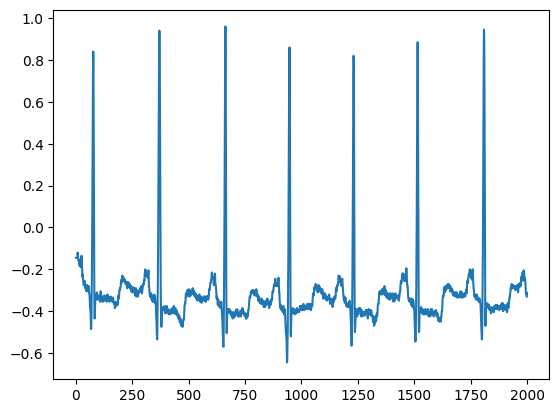

In [ ]:
import matplotlib.pyplot as plt
ecg_signal = record.p_signal[:, 0]  #  the ECG signal is in the first channel
plt.plot(ecg_signal[:2000])  # Plot the first 1000 samples to visualize the ECG signal

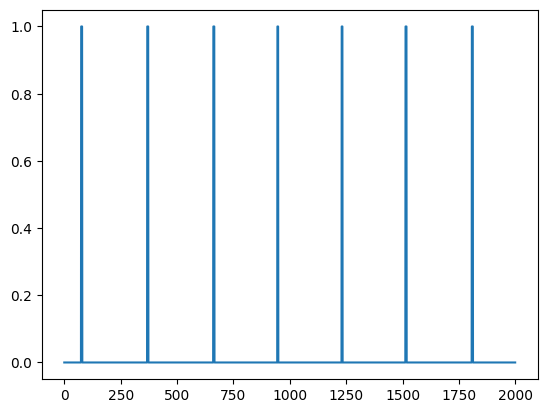

In [31]:
treshold = 0.5
high = (ecg_signal > treshold) # find where the signal is above the threshold
plt.plot(high[:2000])  # Plot the first 1000 samples to visualize the


In [18]:
import numpy as np
onsets = np.where(np.diff(high*1.) == 1)[0] # Find rising edges (onsets)

In [ ]:
# time between two heartbeats in seconds
dt=1/fs # dt is the duration of one sample in seconds
dts = np.diff(onsets)*dt # Convert sample differences to time differences in seconds
print(dts[:10])

[0.81388889 0.81388889 0.78888889 0.79166667 0.78611111 0.81666667
 0.65277778 0.99722222 0.84166667 0.81111111]


In [34]:
rr = dts*1000 # rr in miliseconds
print(rr[:10])

[813.88888889 813.88888889 788.88888889 791.66666667 786.11111111
 816.66666667 652.77777778 997.22222222 841.66666667 811.11111111]


In [23]:
# calucylate heart rate in beats per minute (BPM)
heart_rate = 60.0 / dts
print(heart_rate[:10])

[73.72013652 73.72013652 76.05633803 75.78947368 76.32508834 73.46938776
 91.91489362 60.16713092 71.28712871 73.97260274]


In [36]:
#calculate the variability of heart rate (HRV) using the standard deviation of the heart rate
hrv = np.std(rr)
print(f'Heart Rate Variability (HRV): {hrv:.4f} ms')

Heart Rate Variability (HRV): 48.0920 ms


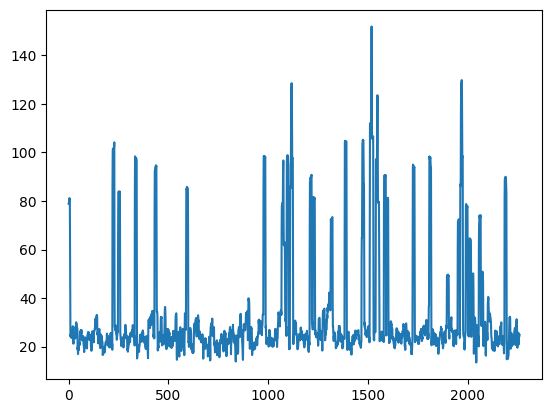

In [37]:
sds = []
nn = 10 # Calculate the standard deviation of the heart rate over a sliding window of 10 beats
for ii in range(len(rr) - nn):
    sds.append(np.std(rr[ii:ii+nn]))
plt.plot(sds)

In [38]:
print(f'Minimum HRV: {np.min(sds):6.3f}')
print(f'Maximum HRV: {np.max(sds):6.3f}')

Minimum HRV: 13.440
Maximum HRV: 151.918


In [39]:
diff_rr = np.diff(rr)
rmssd = np.sqrt(np.mean(diff_rr**2))
print("RMSSD:", rmssd, "ms")

RMSSD: 61.45164407374593 ms


In [40]:
def hrv_metrics(rr):

    rr = np.array(rr)

    # SDNN
    sdnn = np.std(rr, ddof=1)

    # RMSSD
    diff_rr = np.diff(rr)
    rmssd = np.sqrt(np.mean(diff_rr**2))

    # pNN50
    nn50 = np.sum(np.abs(diff_rr) > 50)
    pnn50 = 100 * nn50 / len(diff_rr)

    return sdnn, rmssd, pnn50

sdnn, rmssd, pnn50 = hrv_metrics(rr)
print(f'SDNN: {sdnn:.2f} ms')
print(f'RMSSD: {rmssd:.2f} ms')
print(f'pNN50: {pnn50:.2f} %')

SDNN: 48.10 ms
RMSSD: 61.45 ms
pNN50: 9.60 %


In [ ]:
# simple implementation of finding peaks in the ECG signal 
high = (ecg_signal > treshold) # Converts continuous ECG to binary (above/below threshold)
onsets = np.where(np.diff(high*1.) == 1)[0] # Finds rising edges (0→1 transitions) and Gets indices of those transitions


# use onsets to calculate rr intervals
dt=1/fs 
dts = np.diff(onsets)*dt # 	Calculates time between consecutive onsets 
rr = dts*1000 # Converts seconds to milliseconds
heart_rate = 60.0 / dts # Converts time intervals to beats per minute (BPM)

[  74  367  660  944 1229 1512 1806 2041 2400 2703]


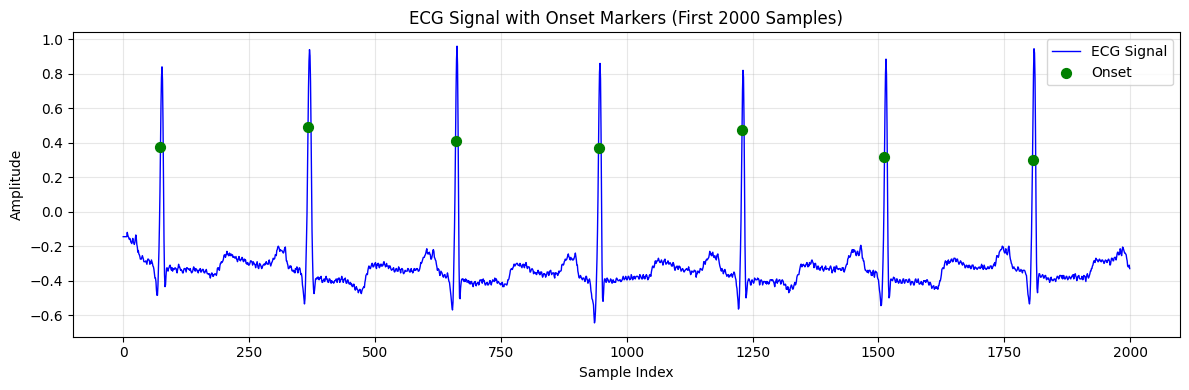

In [47]:
import matplotlib.pyplot as plt

# Plot the ECG signal (first 2000 samples)
plt.figure(figsize=(12, 4))
plt.plot(ecg_signal[:2000], label='ECG Signal', color='blue', linewidth=1)

# Filter onsets to only those within the plotted range
visible_onsets = onsets[onsets < 2000]

# Place green dots at onset locations (only within first 2000 samples)
plt.scatter(visible_onsets, ecg_signal[visible_onsets], color='green', s=50, marker='o', 
            label='Onset', zorder=3)

# Add labels and styling
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('ECG Signal with Onset Markers (First 2000 Samples)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

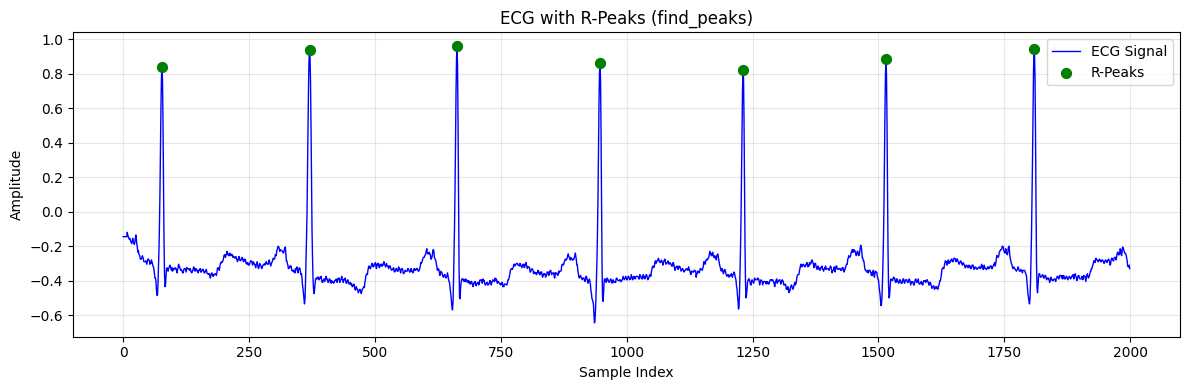

In [53]:
from scipy.signal import find_peaks
threshold = 0.5
peaks, properties = find_peaks(ecg_signal, 
                                height=threshold,           # Minimum amplitude
                                distance=int(0.2*fs),       # Min 200ms between beats
                                prominence=np.std(ecg_signal))  # Prominence filter

# Filter onsets to only those within the plotted range
visible_onsets = peaks[peaks < 2000]

# Plot ECG with detected peaks
plt.figure(figsize=(12, 4))
plt.plot(ecg_signal[:2000], label='ECG Signal', color='blue', linewidth=1)
# Place green dots at onset locations (only within first 2000 samples)
plt.scatter(visible_onsets, ecg_signal[visible_onsets], color='green', s=50, marker='o', 
            label='R-Peaks', zorder=3)
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('ECG with R-Peaks (find_peaks)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [54]:
rr_ms = rr
print(f"Mean RR: {np.mean(rr_ms):.1f} ms")
print(f"Min RR: {np.min(rr_ms):.1f} ms")
print(f"Max RR: {np.max(rr_ms):.1f} ms")


Mean RR: 794.6 ms
Min RR: 519.4 ms
Max RR: 1027.8 ms
